<h3 align="center" style="color:pink">Classification Project</h3>

<h5 style="color:orange">Objective</h5>
<body>To build a Classification ML model to train for Credit Risk modelling using the Loans  dataset provided by Lauki Finance NBFC.</body>

##### 1. Importing Libraries and Dataset

In [394]:
# Numpy, Pandas libraries for data import, processing
import numpy as np
import pandas as pd

# Pyplot, Seaborn libraries for data visualisation
from matplotlib import pyplot as plt
import seaborn as sns

# Train_test_split and Scalers for feature selection, feature processing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Following libraries for training ML model
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

# for model evaluation
from sklearn.metrics import classification_report, r2_score

In [395]:
df_customers = pd.read_csv('customers.csv')
df_bureau = pd.read_csv('bureau_data.csv')
df_loans = pd.read_csv('loans.csv')

In [396]:
print('The shape of customer df is: ',df_customers.shape)
print('The shape of bureau df is: ',df_bureau.shape)
print('The shape of loans df is: ',df_loans.shape)

The shape of customer df is:  (50000, 12)
The shape of bureau df is:  (50000, 8)
The shape of loans df is:  (50000, 15)


In [397]:
df_customers.head(3)

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,Delhi,110001
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,Tamil Nadu,600001
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,West Bengal,700001


In [398]:
df_loans.head(3)

,loan_id,cust_id,loan_purpose,loan_type,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
0,L00001,C00001,Auto,Secured,3004000,2467000,49340.0,444060,1973600,33,1630408,873386,2019-07-24,2019-08-10,False
1,L00002,C00002,Home,Secured,4161000,3883000,77660.0,698940,3106400,30,709309,464100,2019-07-24,2019-08-15,False
2,L00003,C00003,Personal,Unsecured,2401000,2170000,43400.0,390600,1736000,21,1562399,1476042,2019-07-24,2019-08-21,False


In [399]:
df = pd.merge(df_customers, df_loans, on='cust_id')
df.head(3)

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,...,2467000,49340.0,444060,1973600,33,1630408,873386,2019-07-24,2019-08-10,False
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,...,3883000,77660.0,698940,3106400,30,709309,464100,2019-07-24,2019-08-15,False
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,...,2170000,43400.0,390600,1736000,21,1562399,1476042,2019-07-24,2019-08-21,False


In [400]:
df = pd.merge(df, df_bureau)
df.head(3)

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,default,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,...,2019-07-24,2019-08-10,False,1,1,42,0,0,3,7
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,...,2019-07-24,2019-08-15,False,3,1,96,12,60,5,4
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,...,2019-07-24,2019-08-21,False,2,1,82,24,147,6,58


In [401]:
df['default'] = df.default.astype(int)
df.default.value_counts()

default
0    45703
1     4297
Name: count, dtype: int64

In [402]:
# The above inequality in True/False data causes Class imbalance. 
# We can use techniques like SMOT, Undersampling..etc to handle this class imbalance. 

In [403]:
# But we perform train_test_split at this stage only
# and then perform Data cleaning & transformation on Train data and Test data separately. 
# This is to handle the data leakage problem. 

In [404]:
X = df.drop('default', axis='columns')
y = df['default']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.25, random_state=42)

In [405]:
df_train = pd.concat([X_train, y_train], axis='columns')
df_train.head(3)

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,default
12746,C12747,59,M,Married,Self-Employed,11327000,3,Owned,30,Hyderabad,...,2020-10-31,2020-11-11,4,2,152,20,118,4,36,0
32495,C32496,44,F,Single,Salaried,715000,0,Owned,27,Mumbai,...,2022-10-22,2022-10-27,3,1,160,10,62,5,5,0
43675,C43676,38,M,Single,Salaried,3195000,0,Mortgage,26,Chennai,...,2023-12-04,2023-12-29,1,1,54,12,67,4,0,0


In [406]:
df_test = pd.concat([X_test, y_test], axis='columns')
df_test.head(3)

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,default
19205,C19206,36,M,Married,Self-Employed,3728000,3,Owned,24,Jaipur,...,2021-06-24,2021-07-23,2,1,42,0,0,5,98,0
15514,C15515,43,F,Single,Self-Employed,2493000,0,Owned,23,Delhi,...,2021-02-09,2021-02-18,4,0,125,0,0,5,32,0
30367,C30368,30,M,Married,Self-Employed,3114000,4,Owned,27,Delhi,...,2022-08-06,2022-08-21,3,0,76,0,0,6,82,0


In [407]:
df_train.shape, df_test.shape

((37500, 33), (12500, 33))

In [408]:
df_train.columns

Index(['cust_id', 'age', 'gender', 'marital_status', 'employment_status',
       'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode', 'loan_id',
       'loan_purpose', 'loan_type', 'sanction_amount', 'loan_amount',
       'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months',
       'principal_outstanding', 'bank_balance_at_application',
       'disbursal_date', 'installment_start_dt', 'number_of_open_accounts',
       'number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
       'total_dpd', 'enquiry_count', 'credit_utilization_ratio', 'default'],
      dtype='object')

##### 2. Data Cleaning and Exploratory Data Analysis (EDA)

Data Cleaning

In [409]:
# We do data cleaning and exploration on Training dataset
# Starting with identifying NA values

df_train.isnull().sum()

cust_id                         0
age                             0
gender                          0
marital_status                  0
employment_status               0
income                          0
number_of_dependants            0
residence_type                 47
years_at_current_address        0
city                            0
state                           0
zipcode                         0
loan_id                         0
loan_purpose                    0
loan_type                       0
sanction_amount                 0
loan_amount                     0
processing_fee                  0
gst                             0
net_disbursement                0
loan_tenure_months              0
principal_outstanding           0
bank_balance_at_application     0
disbursal_date                  0
installment_start_dt            0
number_of_open_accounts         0
number_of_closed_accounts       0
total_loan_months               0
delinquent_months               0
total_dpd     

In [410]:
df_train['residence_type'].unique()

array(['Owned', 'Mortgage', 'Rented', nan], dtype=object)

In [411]:
# In case of Categorical variable, one meaningful way to fill na values is: Mode (value that appears more frequently)

mode_residence = df_train['residence_type'].mode()[0]
mode_residence

'Owned'

In [412]:
df_train['residence_type'].fillna(mode_residence, inplace=True)
df_train['residence_type'].unique()

C:\Users\VishwambharKulkarni\AppData\Local\Temp\ipykernel_9016\2438764796.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train['residence_type'].fillna(mode_residence, inplace=True)


array(['Owned', 'Mortgage', 'Rented'], dtype=object)

In [413]:
df_test['residence_type'].unique()

array(['Owned', 'Mortgage', 'Rented', nan], dtype=object)

In [414]:
df_test['residence_type'].fillna(df_test['residence_type'].mode()[0], inplace=True)
df_test['residence_type'].unique()

C:\Users\VishwambharKulkarni\AppData\Local\Temp\ipykernel_9016\3145204299.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_test['residence_type'].fillna(df_test['residence_type'].mode()[0], inplace=True)


array(['Owned', 'Mortgage', 'Rented'], dtype=object)

In [415]:
# Checking if there are any duplicates
df_train.duplicated().sum()

np.int64(0)

In [416]:
df_test.duplicated().sum()

np.int64(0)

In [417]:
df_train.columns

Index(['cust_id', 'age', 'gender', 'marital_status', 'employment_status',
       'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode', 'loan_id',
       'loan_purpose', 'loan_type', 'sanction_amount', 'loan_amount',
       'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months',
       'principal_outstanding', 'bank_balance_at_application',
       'disbursal_date', 'installment_start_dt', 'number_of_open_accounts',
       'number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
       'total_dpd', 'enquiry_count', 'credit_utilization_ratio', 'default'],
      dtype='object')

In [418]:
df_train.dtypes.value_counts()

int64      20
object     12
float64     1
Name: count, dtype: int64

In [419]:
numeric_cols = ['age', 'income', 'number_of_dependants', 'years_at_current_address', 
                      'sanction_amount', 'loan_amount', 'processing_fee', 'gst', 'net_disbursement', 
                      'loan_tenure_months','principal_outstanding', 'bank_balance_at_application',
                      'number_of_open_accounts','number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
                       'total_dpd', 'enquiry_count', 'credit_utilization_ratio']

In [420]:
categorical_cols = ['gender', 'marital_status', 'employment_status', 'residence_type', 'city', 
                       'state', 'zipcode', 'loan_purpose', 'loan_type', 'default']

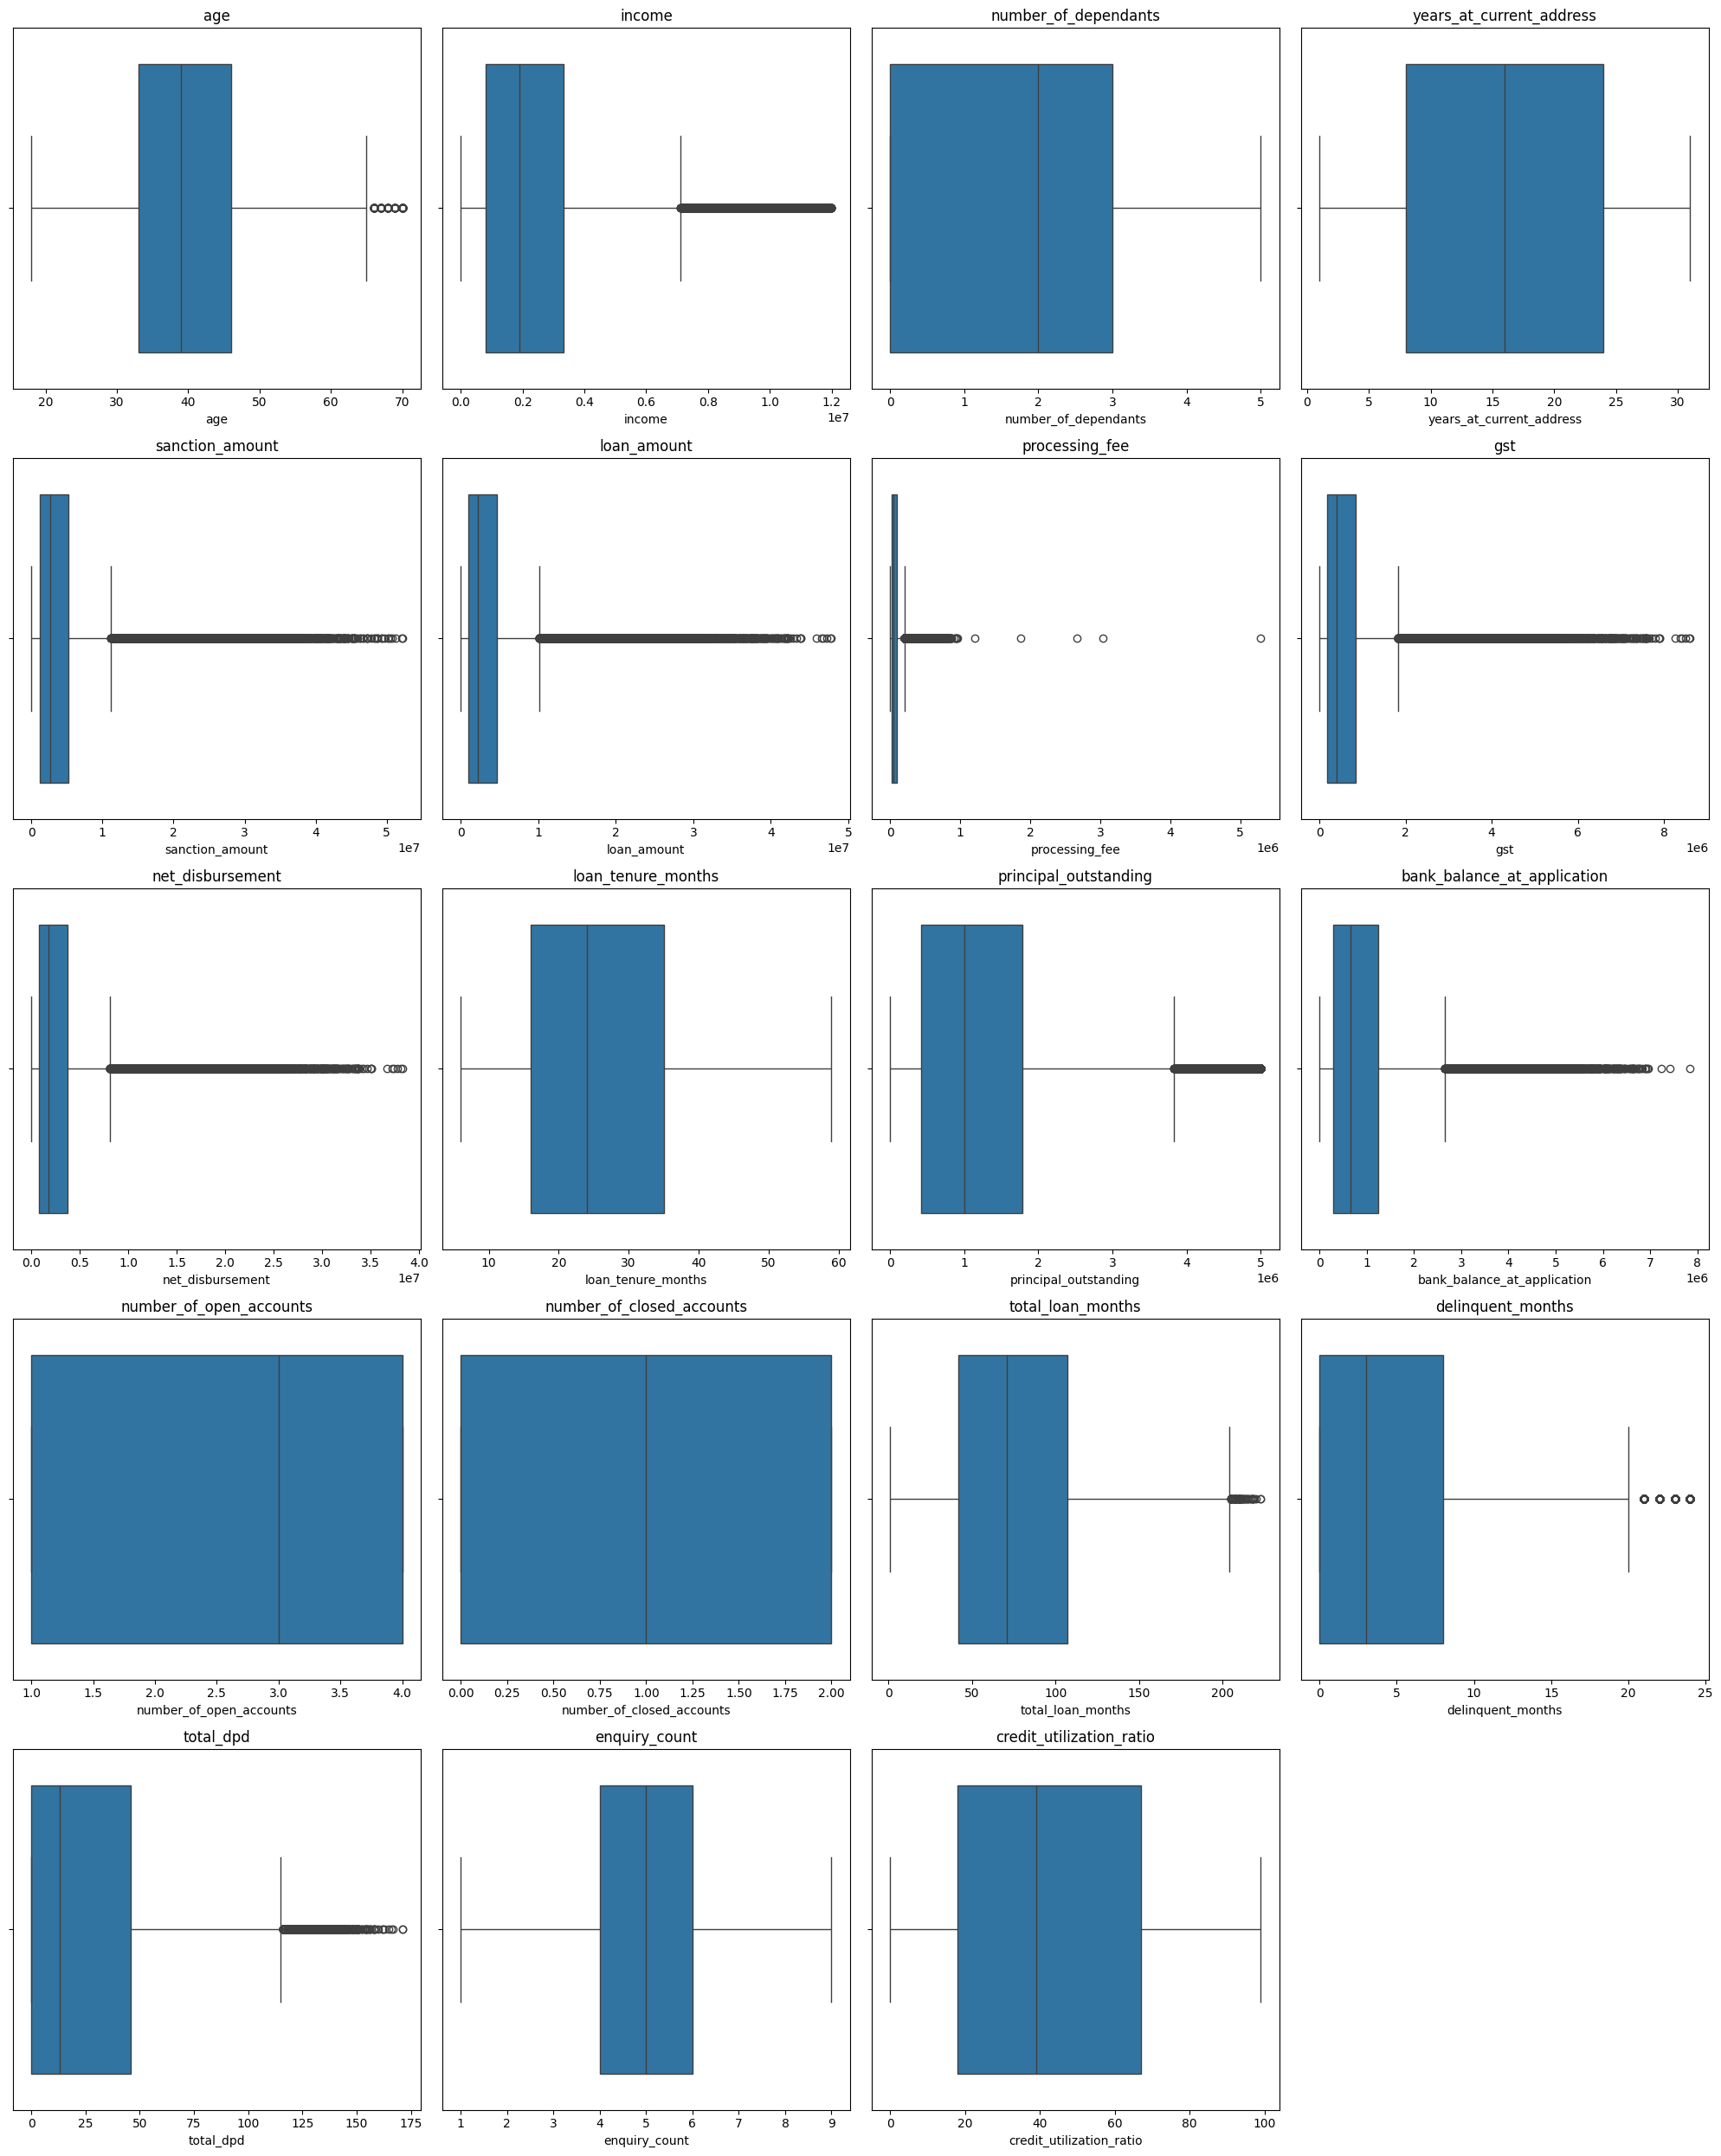

In [421]:
# Box plot for continuous variables

num_plots = len(numeric_cols)
num_cols = 4
num_rows = (num_plots + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(5*num_cols, 5*num_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(x = df_train[col], ax=axes[i])
    axes[i].set_title(col)

for j in range(i + 1, num_rows * num_cols):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

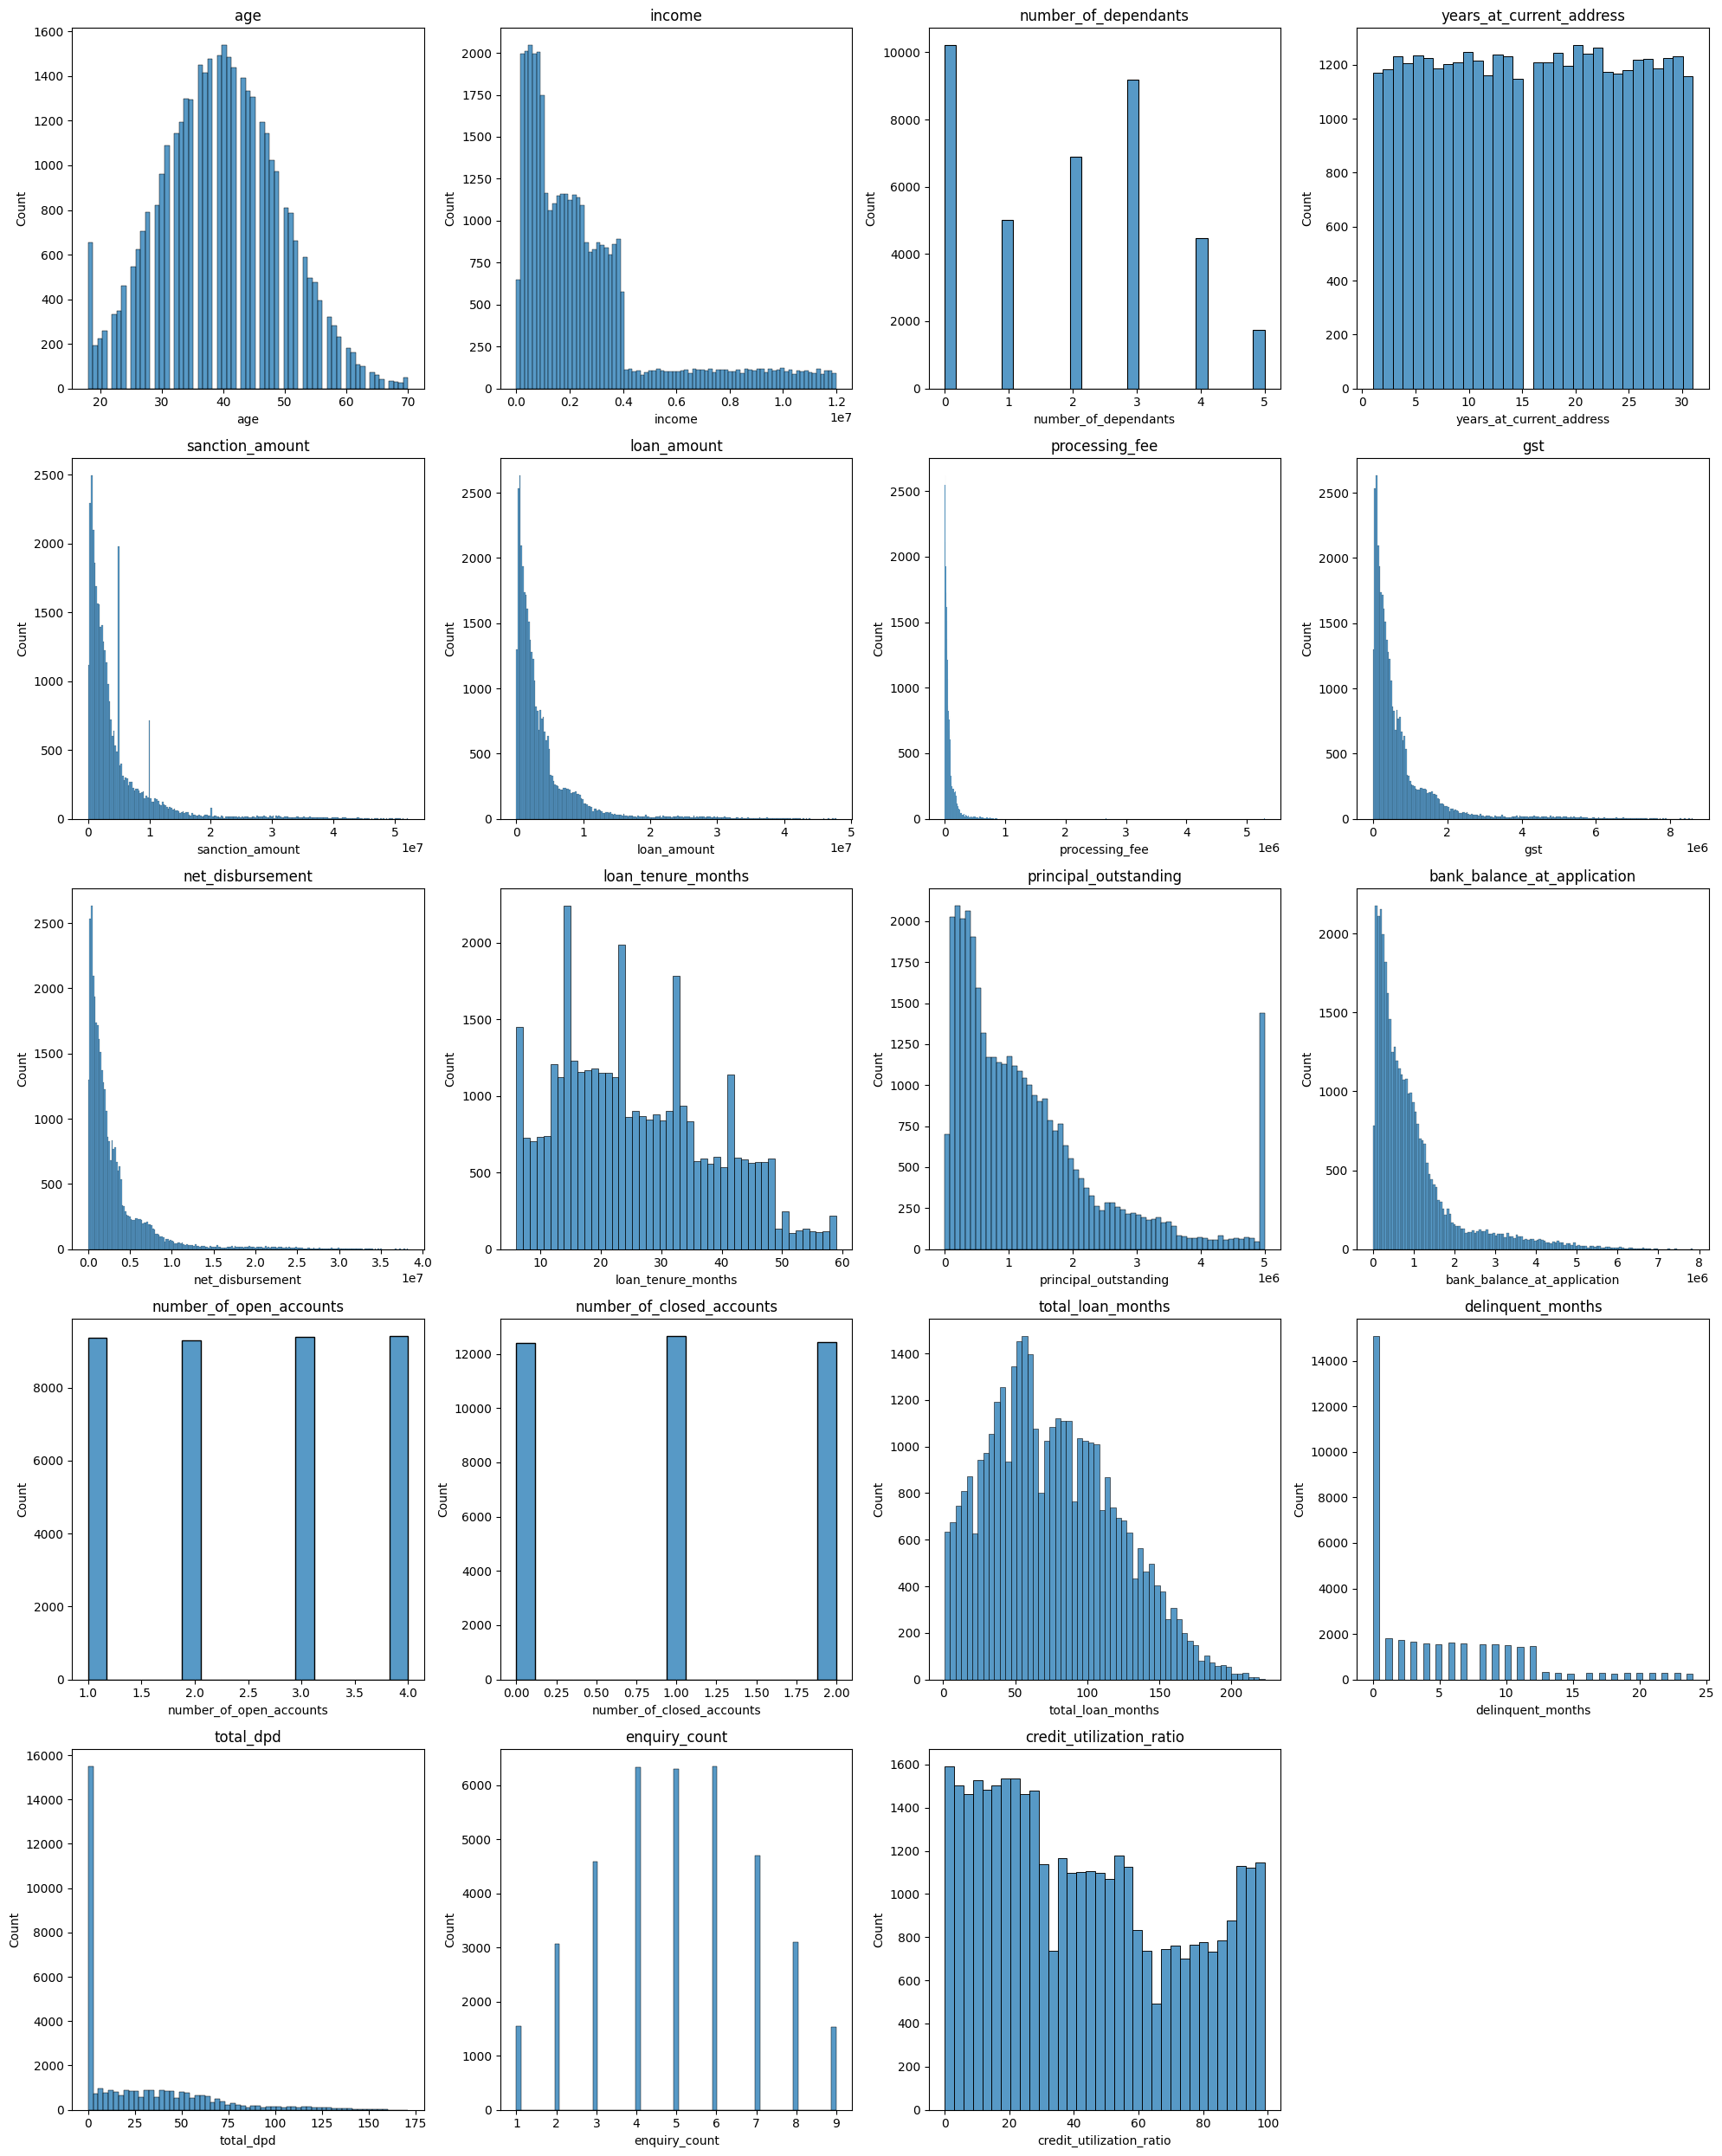

In [422]:
# Hist plot for continuous variables

num_plots = len(numeric_cols)
num_cols = 4
num_rows = (num_plots + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(5*num_cols, 5*num_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(x = df_train[col], ax=axes[i])
    axes[i].set_title(col)

for j in range(i + 1, num_rows * num_cols):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [423]:
# Processing fee column is too much right skewed. 
# Whenever we see such trends, it means there is something wrong with data collected. 
# It doesn't necessarily be true, but we can explore more. 

In [424]:
df_train.processing_fee.describe()

count    3.750000e+04
mean     8.029068e+04
std      1.131281e+05
min      0.000000e+00
25%      1.922000e+04
50%      4.460000e+04
75%      9.242000e+04
max      5.293544e+06
Name: processing_fee, dtype: float64

In [425]:
df_train[df_train['processing_fee']>df_train['loan_amount']][['loan_amount', 'processing_fee']]

,loan_amount,processing_fee
23981,2234000,2.669791e+06
28174,966000,1.214493e+06
47089,1738000,1.858965e+06
29305,2616000,3.036378e+06
9898,3626000,5.293544e+06


In [426]:
# Above data is the rows in which Processing fees is larger than Loan amount itself. 
# From Business understanding, we are aware that Processing fees is never larger than Loan amount. 
# After discussion with Business, it was informed that the processing fees should not be greater than 3% of Loan amount


In [427]:
df_train[(df_train['processing_fee']/df_train['loan_amount'])>0.03][['loan_amount', 'processing_fee']]

,loan_amount,processing_fee
23981,2234000,2.669791e+06
28174,966000,1.214493e+06
47089,1738000,1.858965e+06
29305,2616000,3.036378e+06
9898,3626000,5.293544e+06


In [428]:
df_train_new = df_train[(df_train['processing_fee']/df_train['loan_amount'])<0.03].copy()
df_train_new.shape

(37488, 33)

In [429]:
df_test_new = df_test[(df_test['processing_fee']/df_test['loan_amount'])<0.03].copy()
df_test_new.shape

(12497, 33)

In [430]:
for col in categorical_cols:
    print(col, '==>', df_train_new[col].unique())

gender ==> ['M' 'F']
marital_status ==> ['Married' 'Single']
employment_status ==> ['Self-Employed' 'Salaried']
residence_type ==> ['Owned' 'Mortgage' 'Rented']
city ==> ['Hyderabad' 'Mumbai' 'Chennai' 'Bangalore' 'Pune' 'Kolkata' 'Ahmedabad'
 'Delhi' 'Lucknow' 'Jaipur']
state ==> ['Telangana' 'Maharashtra' 'Tamil Nadu' 'Karnataka' 'West Bengal'
 'Gujarat' 'Delhi' 'Uttar Pradesh' 'Rajasthan']
zipcode ==> [500001 400001 600001 560001 411001 700001 380001 110001 226001 302001]
loan_purpose ==> ['Home' 'Education' 'Personal' 'Auto' 'Personaal']
loan_type ==> ['Secured' 'Unsecured']
default ==> [0 1]


In [431]:
df_train_new['loan_purpose'] = df_train_new['loan_purpose'].replace('Personaal', 'Personal')
df_test_new['loan_purpose'] = df_test_new['loan_purpose'].replace('Personaal', 'Personal')

In [432]:
df_train_new['loan_purpose'].unique()

array(['Home', 'Education', 'Personal', 'Auto'], dtype=object)

In [433]:
df_test_new['loan_purpose'].unique()

array(['Home', 'Education', 'Auto', 'Personal'], dtype=object)

Exploratory Data Analysis

In [434]:
# Exploring how age feature is distributed for default feature
df_train_new.groupby('default')['age'].describe()

,count,mean,std,min,25%,50%,75%,max
default,,,,,,,,
0,34265.0,39.767693,9.880235,18.0,33.0,40.0,46.0,70.0
1,3223.0,37.124729,9.290168,18.0,31.0,37.0,44.0,70.0


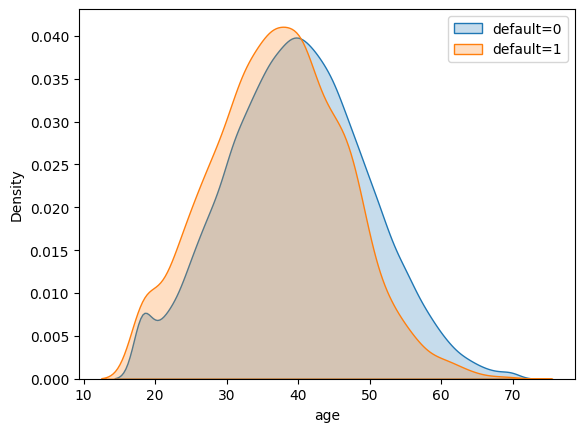

In [435]:
sns.kdeplot(df_train_new['age'][df_train_new['default'] == 0], fill = True, label='default=0')
sns.kdeplot(df_train_new['age'][df_train_new['default'] == 1], fill = True, label='default=1')
plt.legend()
plt.show()

In [436]:
for i,col in enumerate(numeric_cols):
    print(i, '=>', col)

0 => age
1 => income
2 => number_of_dependants
3 => years_at_current_address
4 => sanction_amount
5 => loan_amount
6 => processing_fee
7 => gst
8 => net_disbursement
9 => loan_tenure_months
10 => principal_outstanding
11 => bank_balance_at_application
12 => number_of_open_accounts
13 => number_of_closed_accounts
14 => total_loan_months
15 => delinquent_months
16 => total_dpd
17 => enquiry_count
18 => credit_utilization_ratio


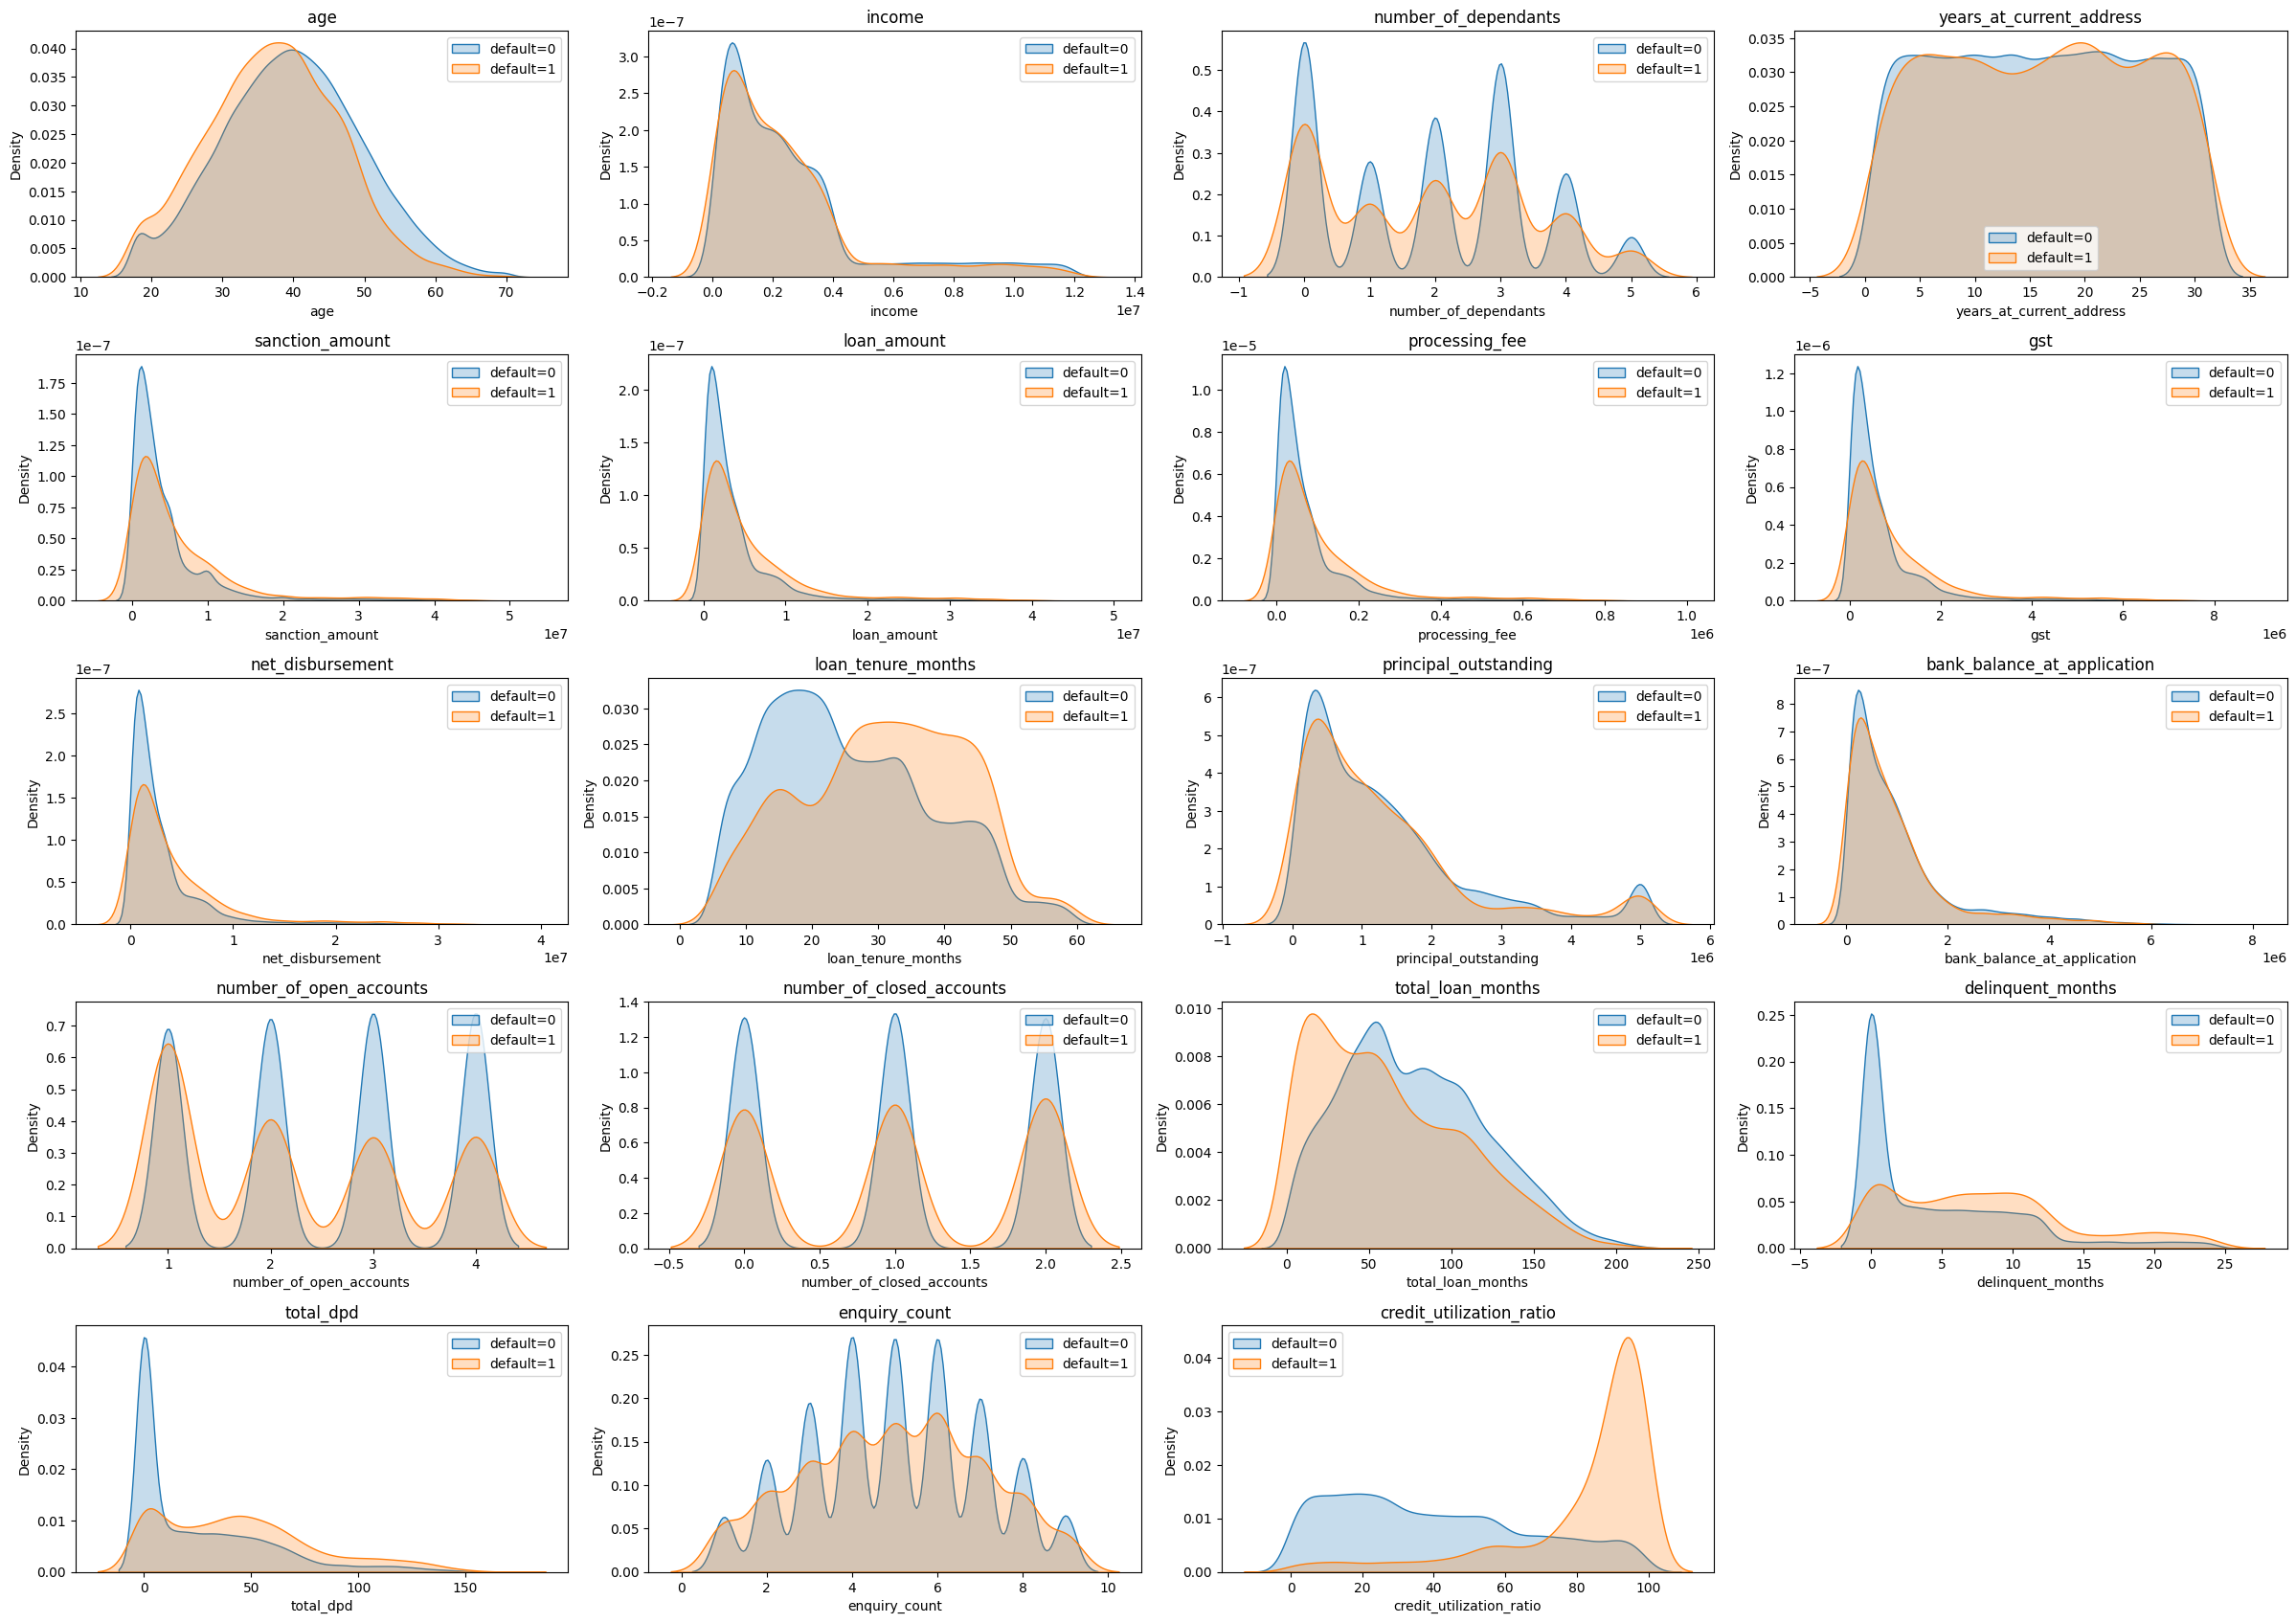

In [437]:
# We next explore how different numerical variables influence the 'Default' variable
# So we plot KDE plot for different features 
plt.figure(figsize=(24, 20))

for i, col in enumerate(numeric_cols):
    plt.subplot(6, 4, i+1)
    sns.kdeplot(df_train_new[col][df_train_new['default'] == 0], fill=True, label='default=0')
    sns.kdeplot(df_train_new[col][df_train_new['default'] == 1], fill=True, label='default=1')
    plt.legend()
    plt.title(col)

plt.tight_layout()
plt.show()

Insights we get from the above plots:
1. People of lesser age are more likely to default on loans, looking at age plot
2. loan_tenure_months, delinquent_months, total_dpd, credit_utilisation_ratio are other important features that determine the target variable 'default'
3. Distribution of remaining columns do not give much insights

##### 3. Feature Engineering

In [438]:
df_train_new.columns

Index(['cust_id', 'age', 'gender', 'marital_status', 'employment_status',
       'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode', 'loan_id',
       'loan_purpose', 'loan_type', 'sanction_amount', 'loan_amount',
       'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months',
       'principal_outstanding', 'bank_balance_at_application',
       'disbursal_date', 'installment_start_dt', 'number_of_open_accounts',
       'number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
       'total_dpd', 'enquiry_count', 'credit_utilization_ratio', 'default'],
      dtype='object')

In [439]:
# As per the inputs from Business, we have the following features we can perform transformation on: 
# 1. Loan to Income ratio 
# 2. Delinquent months to Loan months ratio 
# 3. Average DPD per Delinquent month. 
# Hence, we begin Feature engineering considering these points. 

df_train_new[['loan_amount', 'income']].head()
df_train_new['loan_income_ratio'] = round(df_train_new['loan_amount']/df_train_new['income'], 2)
df_train_new[['loan_amount', 'income', 'loan_income_ratio']].head()

,loan_amount,income,loan_income_ratio
12746,23442000,11327000,2.07
32495,1149000,715000,1.61
43675,11296000,3195000,3.54
9040,1695000,1500000,1.13
13077,905000,1817000,0.50


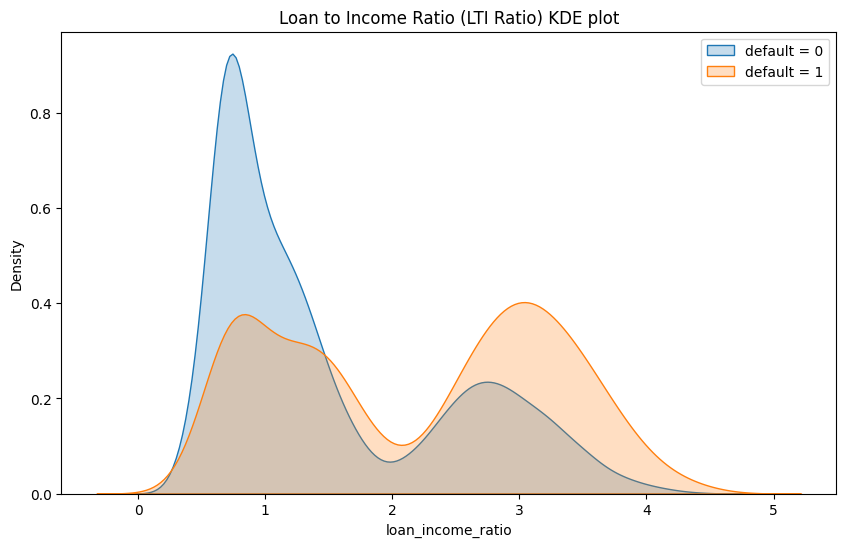

In [440]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df_train_new['loan_income_ratio'][df_train_new['default'] == 0], fill=True, label='default = 0')
sns.kdeplot(df_train_new['loan_income_ratio'][df_train_new['default'] == 1], fill=True, label='default = 1')
plt.title('Loan to Income Ratio (LTI Ratio) KDE plot')
plt.legend()
plt.show()


The above plot shows that: If the Loan to Income ratio is higher => Higher chances of the person defaulting the loan

In [441]:
df_train_new[['delinquent_months', 'total_loan_months']].head()
df_train_new['delinquency_ratio'] = round(df_train_new['delinquent_months']*100 / df_train_new['total_loan_months'], 2)
df_train_new[['delinquent_months', 'total_loan_months', 'delinquency_ratio']].head()

,delinquent_months,total_loan_months,delinquency_ratio
12746,20,152,13.16
32495,10,160,6.25
43675,12,54,22.22
9040,0,76,0.00
13077,0,60,0.00


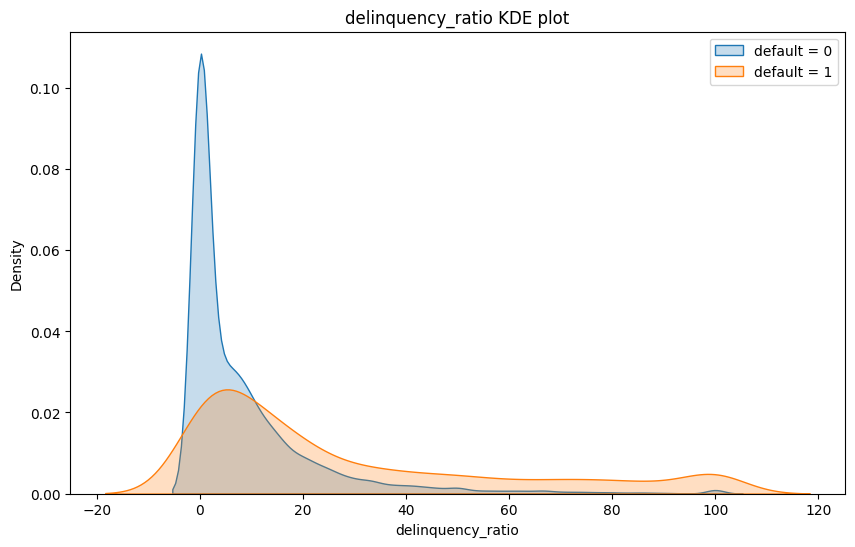

In [442]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df_train_new['delinquency_ratio'][df_train_new['default'] == 0], fill=True, label='default = 0')
sns.kdeplot(df_train_new['delinquency_ratio'][df_train_new['default'] == 1], fill=True, label='default = 1')
plt.title('delinquency_ratio KDE plot')
plt.legend()
plt.show()

Insights: Higher delinquency ratio is related to higher chances of loan being defaulted

In [443]:
df_train_new['Avg_DPD_Delinquent_months_ratio'] = round(df_train_new['total_dpd'] / df_train_new['delinquent_months'], 2)
df_train_new[['total_dpd', 'delinquent_months', 'Avg_DPD_Delinquent_months_ratio']].head()

,total_dpd,delinquent_months,Avg_DPD_Delinquent_months_ratio
12746,118,20,5.90
32495,62,10,6.20
43675,67,12,5.58
9040,0,0,NaN
13077,0,0,NaN


In [444]:
# We find that some values are NaN, which is because delinquent_months were 0 values. 
# Hence, we use a np.where function to filter out

In [445]:
df_train_new['Avg_DPD_Delinquent_months_ratio'] = np.where(
    df_train_new['delinquent_months'] != 0,
    (round(df_train_new['total_dpd'] / df_train_new['delinquent_months'], 2)), 
    0)
df_train_new[['total_dpd', 'delinquent_months', 'Avg_DPD_Delinquent_months_ratio']].head()

,total_dpd,delinquent_months,Avg_DPD_Delinquent_months_ratio
12746,118,20,5.90
32495,62,10,6.20
43675,67,12,5.58
9040,0,0,0.00
13077,0,0,0.00


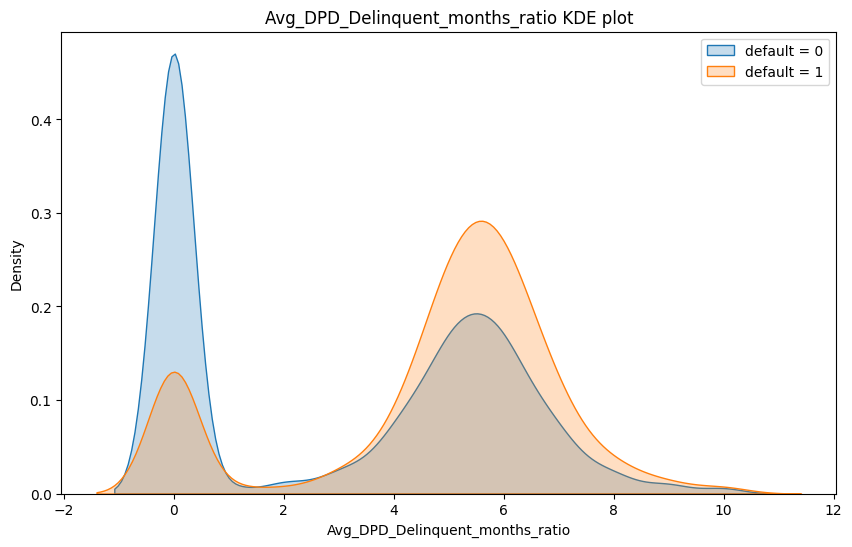

In [446]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df_train_new['Avg_DPD_Delinquent_months_ratio'][df_train_new['default'] == 0], fill=True, label='default = 0')
sns.kdeplot(df_train_new['Avg_DPD_Delinquent_months_ratio'][df_train_new['default'] == 1], fill=True, label='default = 1')
plt.title('Avg_DPD_Delinquent_months_ratio KDE plot')
plt.legend()
plt.show()

Insights: Higher the ratio, higher the chances of loan default

In [447]:
# Perform the above steps for Test dataset also

df_test_new['loan_income_ratio'] = round(df_test_new['loan_amount']/df_test_new['income'], 2)
df_test_new['delinquency_ratio'] = round(df_test_new['delinquent_months']*100 / df_test_new['total_loan_months'], 2)
df_test_new['Avg_DPD_Delinquent_months_ratio'] = np.where(
    df_test_new['delinquent_months'] != 0,
    (round(df_test_new['total_dpd'] / df_test_new['delinquent_months'], 2)), 
    0)

df_test_new.columns

Index(['cust_id', 'age', 'gender', 'marital_status', 'employment_status',
       'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode', 'loan_id',
       'loan_purpose', 'loan_type', 'sanction_amount', 'loan_amount',
       'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months',
       'principal_outstanding', 'bank_balance_at_application',
       'disbursal_date', 'installment_start_dt', 'number_of_open_accounts',
       'number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
       'total_dpd', 'enquiry_count', 'credit_utilization_ratio', 'default',
       'loan_income_ratio', 'delinquency_ratio',
       'Avg_DPD_Delinquent_months_ratio'],
      dtype='object')

Feature Selection

In [448]:
# As per technical understanding, we know that 'cust_id' and 'loan_id' fields have no impact on target variable
# Based on the business inputs, we are told to drop the other variables too: 
# 'disbursal_date', 'installment_start_dt', 'loan_amount', 'income', 'total_loan_months', 'delinquent_months', 'total_dpd'

df_train_3 = df_train_new.drop(['cust_id', 'loan_id', 'disbursal_date', 'installment_start_dt', 'loan_amount', 'income', 'total_loan_months', 'delinquent_months', 'total_dpd'], axis=1)
df_test_3 = df_test_new.drop(['cust_id', 'loan_id', 'disbursal_date', 'installment_start_dt', 'loan_amount', 'income', 'total_loan_months', 'delinquent_months', 'total_dpd'], axis=1)

In [449]:
# We next need to calculate VIF for measuring collinearity. 
# But before calculating VIF, we need to scale the numeric columns. 

X_train = df_train_3.drop(['default'], axis=1)
y_train = df_train_3['default']

scaler = MinMaxScaler()

cols_to_scale = X_train.select_dtypes(['int64', 'float64']).columns

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_train.describe().round(2)



,age,number_of_dependants,years_at_current_address,zipcode,sanction_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,loan_income_ratio,delinquency_ratio,Avg_DPD_Delinquent_months_ratio
count,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00
mean,0.41,0.39,0.50,0.52,0.09,0.08,0.08,0.08,0.38,0.26,0.12,0.50,0.50,0.50,0.44,0.29,0.10,0.33
std,0.19,0.31,0.30,0.29,0.12,0.11,0.11,0.11,0.23,0.24,0.13,0.37,0.41,0.25,0.30,0.23,0.17,0.29
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.29,0.00,0.23,0.33,0.02,0.02,0.02,0.02,0.19,0.08,0.03,0.00,0.00,0.38,0.18,0.11,0.00,0.00
50%,0.40,0.40,0.50,0.49,0.05,0.05,0.05,0.05,0.34,0.19,0.08,0.67,0.50,0.50,0.39,0.20,0.04,0.43
75%,0.54,0.60,0.77,0.76,0.10,0.10,0.10,0.10,0.55,0.35,0.16,1.00,1.00,0.62,0.68,0.51,0.13,0.57
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


In [450]:
X_test = df_test_3.drop(['default'], axis=1)
y_test = df_test_3['default']

X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])
X_test.describe()

,age,number_of_dependants,years_at_current_address,zipcode,sanction_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,loan_income_ratio,delinquency_ratio,Avg_DPD_Delinquent_months_ratio
count,12497.000000,12497.000000,12497.000000,12497.000000,12497.000000,12497.000000,12497.000000,12497.000000,12497.000000,12497.000000,12497.000000,12497.000000,12497.000000,12497.000000,12497.000000,12497.000000,12497.000000,12497.000000
mean,0.415001,0.384892,0.502697,0.525015,0.089218,0.082800,0.082800,0.082800,0.375092,0.264632,0.124944,0.497293,0.500440,0.501470,0.436038,0.293038,0.106077,0.333862
std,0.188773,0.306871,0.298103,0.286179,0.120844,0.112877,0.112877,0.112877,0.233792,0.245290,0.134708,0.372576,0.407226,0.253618,0.295418,0.226176,0.173082,0.289688
min,0.000000,0.000000,0.000000,0.000000,-0.000019,-0.000126,-0.000126,-0.000126,0.000000,0.000163,0.000668,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.288462,0.000000,0.233333,0.325424,0.020958,0.019387,0.019387,0.019387,0.188679,0.079715,0.034167,0.000000,0.000000,0.375000,0.181818,0.112412,0.000000,0.000000
50%,0.423077,0.400000,0.500000,0.510169,0.050189,0.046249,0.046249,0.046249,0.339623,0.198239,0.084024,0.333333,0.500000,0.500000,0.393939,0.201405,0.042100,0.440000
75%,0.538462,0.600000,0.766667,0.762712,0.097422,0.094927,0.094927,0.094927,0.547170,0.356914,0.157792,0.666667,1.000000,0.625000,0.676768,0.498829,0.133900,0.575000
max,1.000000,1.000000,1.000000,1.000000,0.981249,0.963717,0.963717,0.963717,1.000000,1.000000,0.939154,1.000000,1.000000,1.000000,1.000000,1.004684,1.000000,1.000000


In [451]:
# Calculating VIF

from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df['Columns'] = data.columns
    vif_df['VIF'] = [variance_inflation_factor(data.values, i) for i in range(data.shape[1])]
    return vif_df

In [452]:
calculate_vif(X_train[cols_to_scale])

c:\Users\VishwambharKulkarni\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Columns,VIF
0,age,5.700688
1,number_of_dependants,2.730311
2,years_at_current_address,3.422571
3,zipcode,3.797517
4,sanction_amount,101.086587
5,processing_fee,inf
6,gst,inf
7,net_disbursement,inf
8,loan_tenure_months,6.180526
9,principal_outstanding,16.326463


In [453]:
# From what we can see in the above table, 
# 1. processing_fee, gst, net_disbursement - they have infinite VIF score. So, they should be removed. 
# 2. The other columns: sanction_amount and principal_outstanding - they have high VIF score. They also should be removed. 
# Ideally, they should be removed one after other column, starting from the one with highest VIF. 
# Here, we are removing all these columns in single step. 

X_train_new = X_train.drop(['sanction_amount', 'processing_fee', 'gst', 'net_disbursement', 'principal_outstanding'], axis=1)
X_train_new.shape

(37488, 21)

In [454]:
numeric_columns = X_train_new.select_dtypes(['int64', 'float64']).columns
calculate_vif(X_train_new[numeric_columns])

,Columns,VIF
0,age,5.429192
1,number_of_dependants,2.726773
2,years_at_current_address,3.403705
3,zipcode,3.777877
4,loan_tenure_months,6.018731
5,bank_balance_at_application,1.804695
6,number_of_open_accounts,4.353476
7,number_of_closed_accounts,2.372444
8,enquiry_count,6.384090
9,credit_utilization_ratio,2.919834


In [455]:
calculate_vif(X_test[cols_to_scale])

c:\Users\VishwambharKulkarni\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Columns,VIF
0,age,5.805156
1,number_of_dependants,2.717677
2,years_at_current_address,3.431427
3,zipcode,3.803358
4,sanction_amount,102.433811
5,processing_fee,inf
6,gst,inf
7,net_disbursement,inf
8,loan_tenure_months,5.999819
9,principal_outstanding,16.051653


In [456]:
X_test_new = X_test.drop(['sanction_amount', 'processing_fee', 'gst', 'net_disbursement', 'principal_outstanding'], axis=1)
calculate_vif(X_test_new[numeric_columns])

,Columns,VIF
0,age,5.536124
1,number_of_dependants,2.713575
2,years_at_current_address,3.419136
3,zipcode,3.782059
4,loan_tenure_months,5.856022
5,bank_balance_at_application,1.802817
6,number_of_open_accounts,4.269298
7,number_of_closed_accounts,2.373668
8,enquiry_count,6.315073
9,credit_utilization_ratio,2.916067


Feature Selection - Categorical features

In [457]:
# In case of Categorical features, predictive power of a feature is measured by Information Value (IV). 
# IV < 0.02 => Very weak predictive power
# IV b/n 0.02 - 0.1 => Weak predictive power
# 0.1 - 0.3 => Medium
# 0.3 - 0.5 => Strong  
# IV > 0.5 => Very strong predictive power

In [458]:
categorical_cols

['gender',
 'marital_status',
 'employment_status',
 'residence_type',
 'city',
 'state',
 'zipcode',
 'loan_purpose',
 'loan_type',
 'default']

In [459]:
def calculate_woe_iv(df, feature, target):
    grouped_df = df.groupby(feature)[target].agg(['count', 'sum'])
    grouped_df = grouped_df.rename(columns={'count': 'total', 'sum': 'good'})
    grouped_df['bad'] = grouped_df['total'] - grouped_df['good']

    total_good = grouped_df['good'].sum()
    total_bad = grouped_df['bad'].sum()

    grouped_df['good_pct'] = grouped_df['good'] / total_good
    grouped_df['bad_pct'] = grouped_df['bad'] / total_bad

    grouped_df['woe'] = np.log(grouped_df['good_pct'] / grouped_df['bad_pct'])
    grouped_df['iv'] = grouped_df['woe'] * (grouped_df['good_pct'] - grouped_df['bad_pct'])

    grouped_df['woe'] = grouped_df['woe'].replace([-np.inf, np.inf], 0)
    grouped_df['iv'] = grouped_df['iv'].replace([-np.inf, np.inf], 0)

    total_iv = grouped_df['iv'].sum()

    return grouped_df, total_iv

In [460]:
# let's try this function for 'loan_purpose' feature

grouped, iv = calculate_woe_iv(pd.concat([X_train_new, y_train], axis=1), 'loan_purpose', 'default')
grouped

,total,good,bad,good_pct,bad_pct,woe,iv
loan_purpose,,,,,,,
Auto,7447,327,7120,0.101458,0.207792,-0.716891,0.076230
Education,5620,559,5061,0.173441,0.147702,0.160642,0.004135
Home,11304,1734,9570,0.538008,0.279294,0.655609,0.169616
Personal,13117,603,12514,0.187093,0.365212,-0.668874,0.119140


In [461]:
# Now, we calculate IV values for all categorical features. 
# we start by creating a dictionary of IV values

IV_values = {}

for feature in X_train_new.columns:
    if X_train_new[feature].dtype == 'object':
        _, iv = calculate_woe_iv(pd.concat([X_train_new, y_train], axis=1), feature, 'default') # because we need only iv

    else:
        X_binned = pd.cut(X_train_new[feature], bins=10, labels=False)
        _, iv = calculate_woe_iv(pd.concat([X_binned, y_train], axis=1), feature, 'default')

    IV_values[feature] = iv

IV_values

{'age': np.float64(0.0890689462679479),
 'gender': np.float64(0.00047449502170914947),
 'marital_status': np.float64(0.001129766845390142),
 'employment_status': np.float64(0.003953046301722585),
 'number_of_dependants': np.float64(0.0019380899135053508),
 'residence_type': np.float64(0.246745268718145),
 'years_at_current_address': np.float64(0.0020800513608156363),
 'city': np.float64(0.0019059578709781529),
 'state': np.float64(0.0019005589806779287),
 'zipcode': np.float64(0.0016677413243392572),
 'loan_purpose': np.float64(0.3691197842282755),
 'loan_type': np.float64(0.16319324904149224),
 'loan_tenure_months': np.float64(0.21893515090196278),
 'bank_balance_at_application': np.float64(0.0063187993277516365),
 'number_of_open_accounts': np.float64(0.08463134083005877),
 'number_of_closed_accounts': np.float64(0.0011964272592421567),
 'enquiry_count': np.float64(0.007864214085342608),
 'credit_utilization_ratio': np.float64(2.352965568168245),
 'loan_income_ratio': np.float64(0.47

In [462]:
iv_df = pd.DataFrame(list(IV_values.items()), columns=['Feature', 'IV'])
iv_df = iv_df.sort_values(by='IV', ascending=False)
iv_df

,Feature,IV
17,credit_utilization_ratio,2.352966
19,delinquency_ratio,0.716576
18,loan_income_ratio,0.476415
20,Avg_DPD_Delinquent_months_ratio,0.401766
10,loan_purpose,0.369120
5,residence_type,0.246745
12,loan_tenure_months,0.218935
11,loan_type,0.163193
0,age,0.089069
14,number_of_open_accounts,0.084631


In [463]:
# As per Theory, we select those features which have IV value greater than 0.02

selected_features = [feature for feature, iv in IV_values.items() if iv > 0.02]
selected_features

['age',
 'residence_type',
 'loan_purpose',
 'loan_type',
 'loan_tenure_months',
 'number_of_open_accounts',
 'credit_utilization_ratio',
 'loan_income_ratio',
 'delinquency_ratio',
 'Avg_DPD_Delinquent_months_ratio']

In [464]:
# As last step to feature engineering, we perform Feature encoding to the features we have selected

X_train_reduced = X_train_new[selected_features]
X_test_reduced = X_test_new[selected_features]

In [465]:
X_train_encoded = pd.get_dummies(X_train_reduced, drop_first=True)
X_test_encoded = pd.get_dummies(X_test_reduced, drop_first=True)


In [466]:
X_test_encoded.head()

,age,loan_tenure_months,number_of_open_accounts,credit_utilization_ratio,loan_income_ratio,delinquency_ratio,Avg_DPD_Delinquent_months_ratio,residence_type_Owned,residence_type_Rented,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal,loan_type_Unsecured
19205,0.346154,0.754717,0.333333,0.989899,0.550351,0.0000,0.000,True,False,False,True,False,False
15514,0.480769,0.226415,1.000000,0.323232,0.220141,0.0000,0.000,True,False,True,False,False,False
30367,0.230769,0.547170,0.666667,0.828283,0.180328,0.0000,0.000,True,False,False,False,False,False
35347,0.365385,0.754717,1.000000,0.484848,0.571429,0.0240,0.700,True,False,False,True,False,False
41814,0.576923,0.716981,0.666667,0.979798,0.407494,0.1069,0.636,False,False,False,True,False,False


##### 4. Model Training

In [467]:
# Attempt 1: Logistic Regression, without handling class imbalance 

model_lr = LogisticRegression()
model_lr.fit(X_train_encoded, y_train)
y_pred = model_lr.predict(X_test_encoded)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11423
           1       0.85      0.72      0.78      1074

    accuracy                           0.96     12497
   macro avg       0.91      0.86      0.88     12497
weighted avg       0.96      0.96      0.96     12497



In [468]:
# Business requires that recall to be greater than 90%. 
# Try other models too

# Decision Tree classifier
model_dt = DecisionTreeClassifier()
model_dt.fit(X_train_encoded, y_train)
y_pred = model_dt.predict(X_test_encoded)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.97      0.97      0.97     11423
           1       0.71      0.70      0.70      1074

    accuracy                           0.95     12497
   macro avg       0.84      0.84      0.84     12497
weighted avg       0.95      0.95      0.95     12497



In [469]:
# Random Forest classifier
model_rf = RandomForestClassifier()
model_rf.fit(X_train_encoded, y_train)
y_pred = model_rf.predict(X_test_encoded)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11423
           1       0.86      0.71      0.78      1074

    accuracy                           0.96     12497
   macro avg       0.92      0.85      0.88     12497
weighted avg       0.96      0.96      0.96     12497



In [470]:
# XG Boost classifier
model_xgb = XGBClassifier()
model_xgb.fit(X_train_encoded, y_train)
y_pred = model_xgb.predict(X_test_encoded)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.98      0.98      0.98     11423
           1       0.82      0.76      0.79      1074

    accuracy                           0.96     12497
   macro avg       0.90      0.87      0.88     12497
weighted avg       0.96      0.96      0.96     12497



In [471]:
# Attempt 2: Handling class imbalance using Under sampling method

from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler()
X_train_rus, y_train_rus = rus.fit_resample(X_train_encoded, y_train)

In [472]:
model_lr_rus = LogisticRegression()
model_lr_rus.fit(X_train_rus, y_train_rus)
y_pred = model_lr_rus.predict(X_test_encoded)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.91      0.95     11423
           1       0.50      0.96      0.66      1074

    accuracy                           0.91     12497
   macro avg       0.75      0.93      0.80     12497
weighted avg       0.95      0.91      0.93     12497



In [473]:
# Notice that the Recall has improved significantly from the previous time we tried Logistic regression. Let's try Random forest classifier

model_rf_rus = RandomForestClassifier()
model_rf_rus.fit(X_train_rus, y_train_rus)
y_pred = model_rf_rus.predict(X_test_encoded)
report = classification_report(y_test, y_pred)
print(report)



              precision    recall  f1-score   support

           0       1.00      0.91      0.95     11423
           1       0.51      0.97      0.67      1074

    accuracy                           0.92     12497
   macro avg       0.75      0.94      0.81     12497
weighted avg       0.96      0.92      0.93     12497



In [474]:
# XG Boost classifier
model_xgb_rus = XGBClassifier()
model_xgb_rus.fit(X_train_rus, y_train_rus)
y_pred = model_xgb_rus.predict(X_test_encoded)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.92      0.96     11423
           1       0.54      0.96      0.69      1074

    accuracy                           0.93     12497
   macro avg       0.77      0.94      0.83     12497
weighted avg       0.96      0.93      0.94     12497



In [475]:
# Attempt 3: Handling class imbalance using Oversampling technique: SMOTE tomek

from imblearn.combine import SMOTETomek

smt = SMOTETomek(random_state=50)
X_train_smt, y_train_smt = smt.fit_resample(X_train_encoded, y_train)

In [476]:
model_lr_smt = LogisticRegression()
model_lr_smt.fit(X_train_smt, y_train_smt)
y_pred = model_lr_smt.predict(X_test_encoded)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.99      0.93      0.96     11423
           1       0.55      0.94      0.70      1074

    accuracy                           0.93     12497
   macro avg       0.77      0.94      0.83     12497
weighted avg       0.96      0.93      0.94     12497



In [477]:
# We have achieved 90% accuracy and 90% Recall score, which was the Business requirement. 
# But for further model improvement, we can optimize our parameters. 
# For optimizing model parameters, we use Optuna

Using Optuna for Hyperparameter optimization

In [478]:
import optuna
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import cross_val_score


In [479]:
## STEP 1: Define Objective function

def objective(trial):
    # we first define the parameters in objective function
    # since we are using Logistic regression model, the hyperparameters are: C, solver, tolerance, class_weights

    params = {
        'C': trial.suggest_float('C', 1e-4, 1e4, log=True),  # This means, C can have 'logarithmically' spaced values from 1e-4 to 1e4
        'solver': trial.suggest_categorical('solver', ['lbfgs', 'liblinear', 'saga', 'newton-cg']), # These are the solver parameters for Logistic regression
        'tol': trial.suggest_float('tol', 1e-6, 1e-1, log=True), # tolerance could be logarithmically spaced between 1e-6 and 1e-1
        'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced']) # Weight parameter could be None or balanced
    }

    model = LogisticRegression(**params, max_iter=10000)

    # Calculate the scores
    f1_scores = make_scorer(f1_score, average='macro')
    scores = cross_val_score(model, X_train_smt, y_train_smt, cv=3, scoring=f1_scores, n_jobs=-1)

    # return the mean of scores, which will be accuracy of the model
    return np.mean(scores)

## STEP 2: create_study function
study_logistic = optuna.create_study(direction='maximize')  # Create_study method of optuna. Direction = maximise because we need to maximise accuracy

## STEP 3: optimize function
study_logistic.optimize(objective, n_trials=20) # Optimization function - we are using f1 score, which is mentioned above

[I 2026-02-17 08:42:17,556] A new study created in memory with name: no-name-1ec781be-67c2-4e0b-947b-51b772f2e8a3
[I 2026-02-17 08:42:24,146] Trial 0 finished with value: 0.9462712863627504 and parameters: {'C': 690.4347724008493, 'solver': 'saga', 'tol': 6.6956315318853e-05, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.9462712863627504.
[I 2026-02-17 08:42:26,728] Trial 1 finished with value: 0.9446844579067335 and parameters: {'C': 0.3469683180285939, 'solver': 'saga', 'tol': 2.350424933044123e-06, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.9462712863627504.
[I 2026-02-17 08:42:28,610] Trial 2 finished with value: 0.9462567482262539 and parameters: {'C': 1900.349672949254, 'solver': 'lbfgs', 'tol': 6.0328789949640696e-05, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.9462712863627504.
[I 2026-02-17 08:42:30,738] Trial 3 finished with value: 0.9450659596914455 and parameters: {'C': 0.44487970856331527, 'solver': 'saga', 'tol': 0.0002218199736

In [480]:
print('Best Trial: ')
trial = study_logistic.best_trial

print('\tF1 score: {}\t'.format(trial.value))
print('\tParams: \t')

for key, value in trial.params.items():
    print('\t\t{}: {}\t'.format(key, value))

# Creating best model out of best parameters from study_logistic
best_model = LogisticRegression(**study_logistic.best_params)

# Training and predicting based on best model
best_model.fit(X_train_smt, y_train_smt)
y_pred_opt = best_model.predict(X_test_encoded)

print('\n\t CLASSIFICATION REPORT:')
print(classification_report(y_test, y_pred_opt))


Best Trial: 
	F1 score: 0.9462858013071015	
	Params: 	
		C: 72.1700820379827	
		solver: liblinear	
		tol: 0.0006825611770639711	
		class_weight: balanced	

	 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.99      0.93      0.96     11423
           1       0.56      0.94      0.70      1074

    accuracy                           0.93     12497
   macro avg       0.78      0.94      0.83     12497
weighted avg       0.96      0.93      0.94     12497



##### 5. Model evaluation

Model evaluation: ROC and AUC

In [500]:
from sklearn.metrics import roc_curve

probabilities = best_model.predict_proba(X_test_encoded)[:,1]
fpr, tpr, threshold = roc_curve(y_test, probabilities)
# false positive rate, true positive rate, threshold

In [501]:
fpr[:5], tpr[:5], threshold[:5]

(array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 8.75426771e-05,
        8.75426771e-05]),
 array([0.        , 0.0009311 , 0.15828678, 0.15828678, 0.17877095]),
 array([       inf, 1.        , 0.99955168, 0.99954307, 0.99938858]))

In [502]:
from sklearn.metrics import auc

area = auc(fpr, tpr)
area

np.float64(0.9835815909976785)

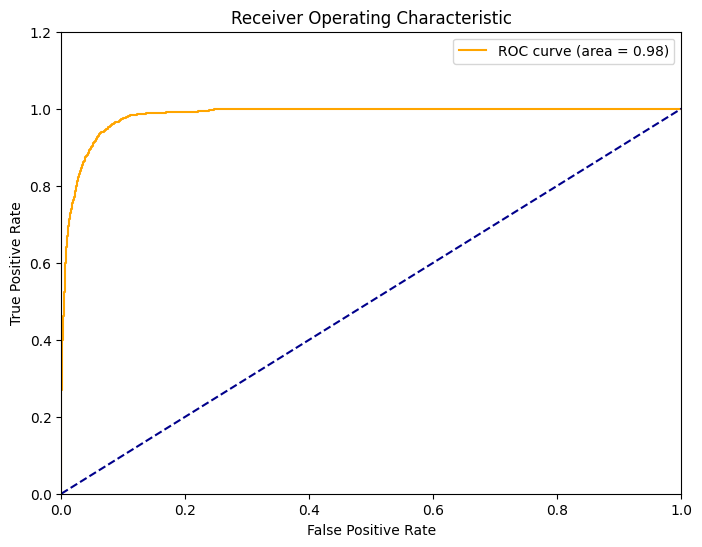

In [503]:
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='orange', label='ROC curve (area = %.2f)'% area)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.2])
plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend()
plt.show()


**Model Evaluation: KS Statistic & Gini Coefficient**

To assess whether rank ordering is followed, we should look at whether higher deciles (those with higher predicted probabilities) have higher event rates compared to lower deciles. Rank ordering means that as you move from the top decile to the bottom decile, the event rate should generally decrease.

Non-Events - termed as good (customers) who do not default. 
Events - termed as bad (customers) who default.

Events and Non-Events terms are interchanged based on usecase to usecase.

eg: for marketing usecase, which customer to reach out (who will take loan based on offers) will be events - here it will termed as good, and the customers who will not take loans will be non-events (bad).


In [504]:
df_eval = pd.DataFrame({
    'Default Truth': y_test,
    'Predicted Probability': probabilities
})

df_eval.head()

,Default Truth,Predicted Probability
19205,0,0.511015
15514,0,0.000009
30367,0,0.004836
35347,0,0.005357
41814,1,0.913520


In [505]:
df_eval['Decile'] = pd.qcut(df_eval['Predicted Probability'], 10, labels=False, duplicates='drop')
df_eval.head()

,Default Truth,Predicted Probability,Decile
19205,0,0.511015,8
15514,0,0.000009,2
30367,0,0.004836,6
35347,0,0.005357,6
41814,1,0.913520,9


In [506]:
df_decile = df_eval.groupby('Decile').apply(lambda x: pd.Series({
    'Minimum Probability': x['Predicted Probability'].min(),
    'Maximum Probability': x['Predicted Probability'].max(),
    'Events': x['Default Truth'].sum(),
    'Non Events': x['Default Truth'].count() - x['Default Truth'].sum()
}))

C:\Users\VishwambharKulkarni\AppData\Local\Temp\ipykernel_9016\1795187755.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_decile = df_eval.groupby('Decile').apply(lambda x: pd.Series({


In [507]:
df_decile.reset_index(inplace=True)
df_decile.head()

,Decile,Minimum Probability,Maximum Probability,Events,Non Events
0,0,7.982854e-10,5.722669e-07,0.0,1250.0
1,1,5.725620e-07,4.646802e-06,0.0,1250.0
2,2,4.654710e-06,2.389254e-05,0.0,1249.0
3,3,2.390965e-05,1.242527e-04,0.0,1250.0
4,4,1.244823e-04,6.415020e-04,0.0,1250.0


In [508]:
df_decile['Event Rate'] = df_decile['Events']*100 / (df_decile['Events'] + df_decile['Non Events'])
df_decile['Non Event Rate'] = df_decile['Non Events']*100 / (df_decile['Events'] + df_decile['Non Events'])
df_decile.head()

,Decile,Minimum Probability,Maximum Probability,Events,Non Events,Event Rate,Non Event Rate
0,0,7.982854e-10,5.722669e-07,0.0,1250.0,0.0,100.0
1,1,5.725620e-07,4.646802e-06,0.0,1250.0,0.0,100.0
2,2,4.654710e-06,2.389254e-05,0.0,1249.0,0.0,100.0
3,3,2.390965e-05,1.242527e-04,0.0,1250.0,0.0,100.0
4,4,1.244823e-04,6.415020e-04,0.0,1250.0,0.0,100.0


In [509]:
df_decile = df_decile.sort_values(by='Decile', ascending=False).reset_index(drop=True)
df_decile.head()

,Decile,Minimum Probability,Maximum Probability,Events,Non Events,Event Rate,Non Event Rate
0,9,0.822934,1.000000,899.0,351.0,71.920000,28.080000
1,8,0.205783,0.821026,161.0,1089.0,12.880000,87.120000
2,7,0.026638,0.205390,9.0,1240.0,0.720576,99.279424
3,6,0.003783,0.026577,5.0,1245.0,0.400000,99.600000
4,5,0.000642,0.003782,0.0,1249.0,0.000000,100.000000


In [510]:
df_decile['Cumulative events'] = df_decile['Events'].cumsum()
df_decile['Cumulative Non Events'] = df_decile['Non Events'].cumsum()
df_decile.head()

,Decile,Minimum Probability,Maximum Probability,Events,Non Events,Event Rate,Non Event Rate,Cumulative events,Cumulative Non Events
0,9,0.822934,1.000000,899.0,351.0,71.920000,28.080000,899.0,351.0
1,8,0.205783,0.821026,161.0,1089.0,12.880000,87.120000,1060.0,1440.0
2,7,0.026638,0.205390,9.0,1240.0,0.720576,99.279424,1069.0,2680.0
3,6,0.003783,0.026577,5.0,1245.0,0.400000,99.600000,1074.0,3925.0
4,5,0.000642,0.003782,0.0,1249.0,0.000000,100.000000,1074.0,5174.0


In [511]:
df_decile['Cum. Event Rate'] = df_decile['Cumulative events']*100 / df_decile['Events'].sum()
df_decile['Cum. Non Event Rate'] = df_decile['Cumulative Non Events']*100 / df_decile['Non Events'].sum()
df_decile.head()

,Decile,Minimum Probability,Maximum Probability,Events,Non Events,Event Rate,Non Event Rate,Cumulative events,Cumulative Non Events,Cum. Event Rate,Cum. Non Event Rate
0,9,0.822934,1.000000,899.0,351.0,71.920000,28.080000,899.0,351.0,83.705773,3.072748
1,8,0.205783,0.821026,161.0,1089.0,12.880000,87.120000,1060.0,1440.0,98.696462,12.606145
2,7,0.026638,0.205390,9.0,1240.0,0.720576,99.279424,1069.0,2680.0,99.534451,23.461437
3,6,0.003783,0.026577,5.0,1245.0,0.400000,99.600000,1074.0,3925.0,100.000000,34.360501
4,5,0.000642,0.003782,0.0,1249.0,0.000000,100.000000,1074.0,5174.0,100.000000,45.294581


In [512]:
df_decile['KS'] = df_decile['Cum. Event Rate'] - df_decile['Cum. Non Event Rate']
df_decile.head()

,Decile,Minimum Probability,Maximum Probability,Events,Non Events,Event Rate,Non Event Rate,Cumulative events,Cumulative Non Events,Cum. Event Rate,Cum. Non Event Rate,KS
0,9,0.822934,1.000000,899.0,351.0,71.920000,28.080000,899.0,351.0,83.705773,3.072748,80.633025
1,8,0.205783,0.821026,161.0,1089.0,12.880000,87.120000,1060.0,1440.0,98.696462,12.606145,86.090316
2,7,0.026638,0.205390,9.0,1240.0,0.720576,99.279424,1069.0,2680.0,99.534451,23.461437,76.073013
3,6,0.003783,0.026577,5.0,1245.0,0.400000,99.600000,1074.0,3925.0,100.000000,34.360501,65.639499
4,5,0.000642,0.003782,0.0,1249.0,0.000000,100.000000,1074.0,5174.0,100.000000,45.294581,54.705419


In [513]:
df_decile

,Decile,Minimum Probability,Maximum Probability,Events,Non Events,Event Rate,Non Event Rate,Cumulative events,Cumulative Non Events,Cum. Event Rate,Cum. Non Event Rate,KS
0,9,8.229344e-01,1.000000e+00,899.0,351.0,71.920000,28.080000,899.0,351.0,83.705773,3.072748,80.633025
1,8,2.057832e-01,8.210262e-01,161.0,1089.0,12.880000,87.120000,1060.0,1440.0,98.696462,12.606145,86.090316
2,7,2.663848e-02,2.053898e-01,9.0,1240.0,0.720576,99.279424,1069.0,2680.0,99.534451,23.461437,76.073013
3,6,3.783271e-03,2.657739e-02,5.0,1245.0,0.400000,99.600000,1074.0,3925.0,100.000000,34.360501,65.639499
4,5,6.424952e-04,3.782094e-03,0.0,1249.0,0.000000,100.000000,1074.0,5174.0,100.000000,45.294581,54.705419
5,4,1.244823e-04,6.415020e-04,0.0,1250.0,0.000000,100.000000,1074.0,6424.0,100.000000,56.237416,43.762584
6,3,2.390965e-05,1.242527e-04,0.0,1250.0,0.000000,100.000000,1074.0,7674.0,100.000000,67.180250,32.819750
7,2,4.654710e-06,2.389254e-05,0.0,1249.0,0.000000,100.000000,1074.0,8923.0,100.000000,78.114331,21.885669
8,1,5.725620e-07,4.646802e-06,0.0,1250.0,0.000000,100.000000,1074.0,10173.0,100.000000,89.057165,10.942835
9,0,7.982854e-10,5.722669e-07,0.0,1250.0,0.000000,100.000000,1074.0,11423.0,100.000000,100.000000,0.000000


**Insights from the Decile Table**

1. Top Deciles

* The first decile (Decile 9) has a high event rate of 71.92% and a non-event rate of 28.00%. This indicates that the model is highly confident in predicting events in this decile.
* The second decile (Decile 8) also shows a significant event rate of 12.88%, with a cumulative event rate reaching 98.6%.

2. Middle Deciles:

* Deciles 7 and 6 show a significant drop in event rates

3. Lower Deciles:

* Deciles 5 to 0 show zero events, with all predictions being non-events. These deciles collectively have a non-event rate of 100%.

4. KS Statistic:

* The KS statistic, which is the maximum difference between cumulative event rates and cumulative non-event rates, is highest at Decile 8 with a value of 86.09%. This suggests that the model performs best at distinguishing between events and non-events up to this decile.

* The KS value gradually decreases in the following deciles, indicating a decrease in model performance for distinguishing between events and non-events.

**KS Value**

The highest KS value is 85.98%, found at Decile 8. This indicates that the model's performance in distinguishing between events and non-events is most significant at this decile. (**If KS is in top 3 decile and score above 40, it is considered a good predictive model.**)

In [515]:
gini_coef = 2*area - 1
print('AUC: ', area)
print('Gini Coefficient: ', gini_coef)

AUC:  0.9835815909976785
Gini Coefficient:  0.967163181995357


AUC of 0.98: The model is very good at distinguishing between events and non-events.

Gini coefficient of 0.96: This further confirms that the model is highly effective in its predictions, with almost perfect rank ordering capability.

The Gini coefficient ranges from -1 to 1, where a value closer to 1 signifies a perfect model, 0 indicates a model with no discriminative power, and -1 signifies a perfectly incorrect model.

In [526]:
# Plotting FEATURE IMPORTANCES

final_model = best_model
feature_importance = final_model.coef_[0]

feature_df = pd.DataFrame(feature_importance, index=X_train_encoded.columns, columns=['Coefficients'])
feature_df = feature_df.sort_values(by='Coefficients', ascending=True)

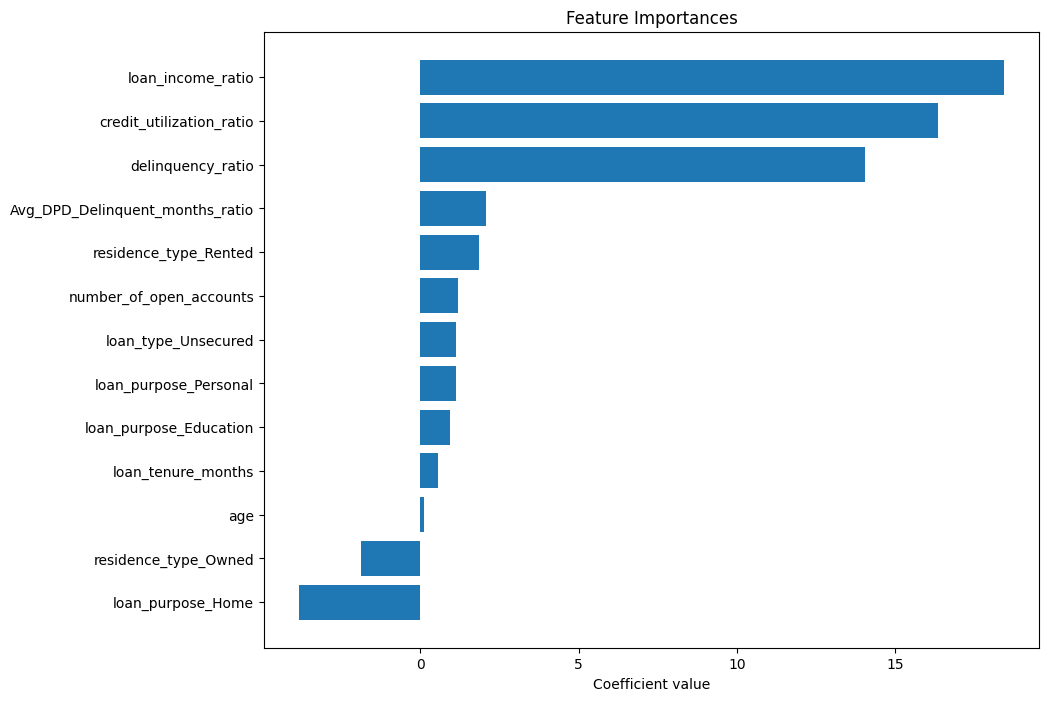

In [527]:
plt.figure(figsize=(10,8))
plt.barh(feature_df.index, feature_df['Coefficients'])
plt.xlabel('Coefficient value')
plt.title('Feature Importances')
plt.show()

In [530]:
X_test_encoded.columns

Index(['age', 'loan_tenure_months', 'number_of_open_accounts',
       'credit_utilization_ratio', 'loan_income_ratio', 'delinquency_ratio',
       'Avg_DPD_Delinquent_months_ratio', 'residence_type_Owned',
       'residence_type_Rented', 'loan_purpose_Education', 'loan_purpose_Home',
       'loan_purpose_Personal', 'loan_type_Unsecured'],
      dtype='object')

In [529]:
cols_to_scale

Index(['age', 'number_of_dependants', 'years_at_current_address', 'zipcode',
       'sanction_amount', 'processing_fee', 'gst', 'net_disbursement',
       'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'number_of_open_accounts',
       'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'loan_income_ratio', 'delinquency_ratio',
       'Avg_DPD_Delinquent_months_ratio'],
      dtype='object')

##### Model Export

In [531]:
from joblib import dump

model_data = {
    'model' : final_model,
    'features' : X_train_encoded.columns,
    'cols_to_scale' : cols_to_scale,
    'scaler' : scaler
}


In [532]:
model_data

{'model': LogisticRegression(C=72.1700820379827, class_weight='balanced',
                    solver='liblinear', tol=0.0006825611770639711),
 'features': Index(['age', 'loan_tenure_months', 'number_of_open_accounts',
        'credit_utilization_ratio', 'loan_income_ratio', 'delinquency_ratio',
        'Avg_DPD_Delinquent_months_ratio', 'residence_type_Owned',
        'residence_type_Rented', 'loan_purpose_Education', 'loan_purpose_Home',
        'loan_purpose_Personal', 'loan_type_Unsecured'],
       dtype='object'),
 'cols_to_scale': Index(['age', 'number_of_dependants', 'years_at_current_address', 'zipcode',
        'sanction_amount', 'processing_fee', 'gst', 'net_disbursement',
        'loan_tenure_months', 'principal_outstanding',
        'bank_balance_at_application', 'number_of_open_accounts',
        'number_of_closed_accounts', 'enquiry_count',
        'credit_utilization_ratio', 'loan_income_ratio', 'delinquency_ratio',
        'Avg_DPD_Delinquent_months_ratio'],
       dtype

In [534]:
dump(model_data, 'artifacts_vishwa/model_data.joblib')

['artifacts_vishwa/model_data.joblib']